# HW 05 - long term tracking

In [172]:
from IPython import display

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [173]:
# !pip install got10k
# !wget http://box.vicos.si/alanl/dataset-lt.zip # dataset
# !wget http://box.vicos.si/alanl/siamfc_net.pth # model checkpoint
display.clear_output()

## Assignment 1 - short term SiamFC tracker

In [174]:
import sys
sys.path.append("./material")

In [175]:
from material.run_tracker import evaluate_tracker
from material.siamfc.siamfc import TrackerSiamFC

DATASET_PATH = "./data"
NETWORK_PATH = "./siamfc_net.pth"
RESULT_DIR = "result_out"

seqences = ['car9', 'cat1', 'deer', 'dog', 'person14', 'person20', 'sitcom', 'skiing', 'sup']

seqence = 'deer'


In [181]:
# results, scores, _, _ =  evaluate_tracker(DATASET_PATH, NETWORK_PATH, RESULT_DIR, False, TrackerSiamFC, [seqence])
results, scores, _, _ =  evaluate_tracker(DATASET_PATH, NETWORK_PATH, RESULT_DIR, False, TrackerSiamFC, seqences)

sup: 100%|██████████| 3505/3505 [01:00<00:00, 57.61it/s]


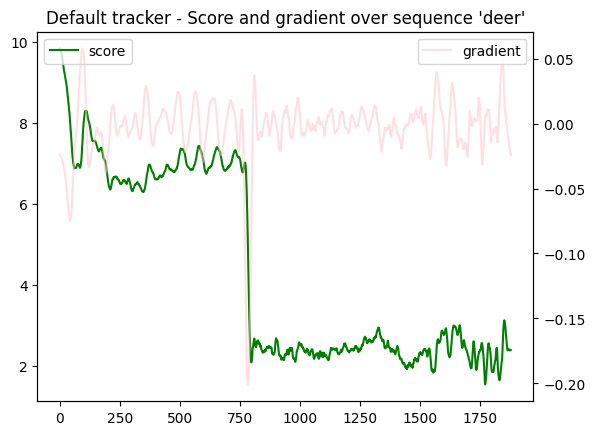

In [177]:
data = np.array(scores[1:]).squeeze()
smooth = savgol_filter(data, 20, 2) # time series smoothing filter
smooth_grad = savgol_filter(np.gradient(smooth, axis=0), 50, 2)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(smooth, label="score", color="green", alpha=1) # ignore first step since the score is super high - a supervised example is know
ax1.legend(loc="upper left")

ax2.plot(smooth_grad, label="gradient", color="pink", alpha=0.5) # ignore first step since the score is super high - a supervised example is know
ax2.legend(loc="upper right")

plt.title(f"Default tracker - Score and gradient over sequence '{seqence}'")
plt.show()

### Evaluate perfromance

In [182]:
from material.performance_evaluation import evaluate_performance

print("DEFAULT TRACKER PERFORMNCE:")
# perf = evaluate_performance(DATASET_PATH, RESULT_DIR,[seqence])
perf = evaluate_performance(DATASET_PATH, RESULT_DIR,seqences)

DEFAULT TRACKER PERFORMNCE:
--------------------------
Precision: 0.6197222817065198
Recall: 0.253086986606732
F-score: 0.3593995859215832
--------------------------


## Assignment 2: Long-term tracker

we need a way for running a model on one sequence and see how the location confidence changes over the occlusio

In [184]:
# load custom model
from material.siamfc.siamfc_long import TrackerSiamFCLong
RESULT_DIR = "results_long_out"
# seqences = ['car9', 'cat1', 'deer', 'dog', 'person14', 'person20', 'sitcom', 'skiing', 'sup']

# run eval
results, scores, visible_ar, tresh_ar = evaluate_tracker(DATASET_PATH, NETWORK_PATH, RESULT_DIR, False, TrackerSiamFCLong, seqences)

sup: 100%|██████████| 3505/3505 [01:31<00:00, 38.32it/s]


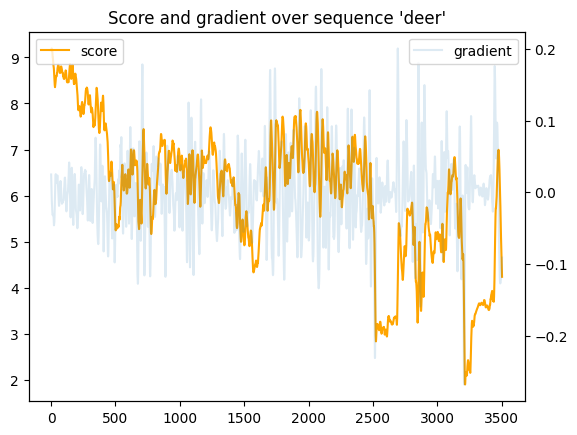

In [185]:


data = np.array(scores[1:]).squeeze()
smooth = savgol_filter(data, 20, 2) # time series smoothing filter
smooth_grad = savgol_filter(np.gradient(smooth, axis=0), 20, 2)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(smooth, label="score", color="orange", alpha=1) # ignore first step since the score is super high - a supervised example is know
ax1.legend(loc="upper left")


ax2.plot(smooth_grad, label="gradient", alpha=0.15) # ignore first step since the score is super high - a supervised example is know
ax2.legend(loc="upper right")


plt.title(f"Score and gradient over sequence '{seqence}'")
plt.show()

### Plan / idea

When we detect a huge negative gradient, we know that the target has been probably lost.  

We can either detect the gradients over the running average or take the ground score value and detect when it drops under the certain threshold.

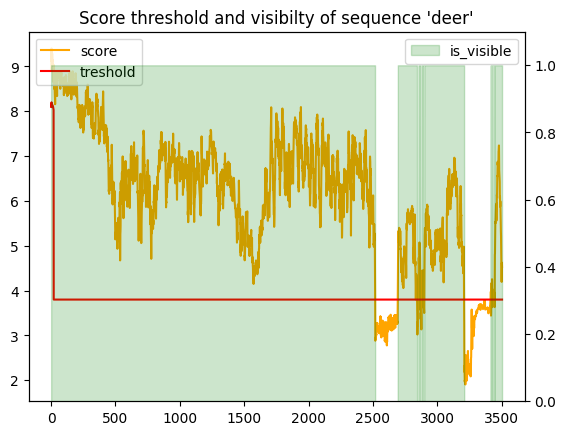

In [186]:
data = np.array(scores[1:]).squeeze()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()


ax1.plot(data, label="score", color="orange", alpha=1) # ignore first step since the score is super high - a supervised example is know
ax1.plot(tresh_ar[1:], label="treshold", color="red", alpha=1) # ignore first step since the score is super high - a supervised example is know
ax1.legend(loc="upper left")

ax2.fill_between(np.arange(len(visible_ar[1:])), visible_ar[1:], label="is_visible", alpha=0.2, color="green") # ignore first step since the score is super high - a supervised example is know
ax2.legend(loc="upper right")

ax2.set_ylim([0, 1.1])

plt.title(f"Score threshold and visibilty of sequence '{seqence}'")
plt.savefig(f"score_tresh_vis'{seqence}'.png")
plt.show()

In [187]:
RESULT_DIR = "results_long_out"
perf = evaluate_performance(DATASET_PATH, RESULT_DIR, seqences)

--------------------------
Precision: 0.5677362805956192
Recall: 0.4116435283439662
F-score: 0.4772509369297753
--------------------------
